# **Installation & Infrastructure :**

In [19]:
# Block 1: Dependencies
!pip install stable-baselines3[extra] gymnasium shimmy matplotlib pandas numpy
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from stable_baselines3 import PPO

# **The "Real-World" Environment (Drift + Jumps):**

This block defines the market physics. We've added a Drift (a constant upward or downward trend) and Jumps (random 5% price spikes/crashes).

In [20]:
class StressTestEnv(gym.Env):
    def __init__(self, drift=0.05, jump_prob=0.03):
        super().__init__()
        self.drift = drift
        self.jump_prob = jump_prob
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)
        self.action_space = gym.spaces.Box(low=0.0, high=5.0, shape=(2,), dtype=np.float32)
        self.reset()

    def reset(self, seed=None):
        self.price, self.inventory, self.cash, self.time = 100.0, 0, 0.0, 1.0
        return np.array([self.price, self.inventory, self.time], dtype=np.float32), {}

    def step(self, action):
        bid_d, ask_d = action
        # Physics: Drift + Brownian Motion + Merton Jumps
        jump = np.random.normal(0, 4.0) if np.random.random() < self.jump_prob else 0
        self.price += self.drift + np.random.normal(0, 1.2) + jump

        # Fill Logic (Poisson-style)
        prob = 140 * np.exp(-1.5 * action) * 0.01
        fills = np.random.random(2) < prob
        if fills[0]: self.inventory += 1; self.cash -= (self.price - bid_d)
        if fills[1]: self.inventory -= 1; self.cash += (self.price + ask_d)

        wealth = self.cash + (self.inventory * self.price)
        self.time -= 0.01
        # Quadratic Penalty: lambda * q^2
        reward = wealth - 0.1 * (self.inventory ** 2)
        return np.array([self.price, self.inventory, self.time], dtype=np.float32), float(reward), (self.time <= 0), False, {"wealth": wealth}

Training the Stress-Resistant Agent

In [21]:
# Block 3: Training
env_a = StressTestEnv()
print("Training Agent A to handle Flash Crashes...")
model_a = PPO("MlpPolicy", env_a, verbose=0).learn(total_timesteps=40000)
print("Training Complete.")

Training Agent A to handle Flash Crashes...
Training Complete.


# **Live Dashboard (Price, Spread, and Wealth):**

This will run a 100-step simulation. The shaded area represents the agent's bid-ask spread wiggling around the price.

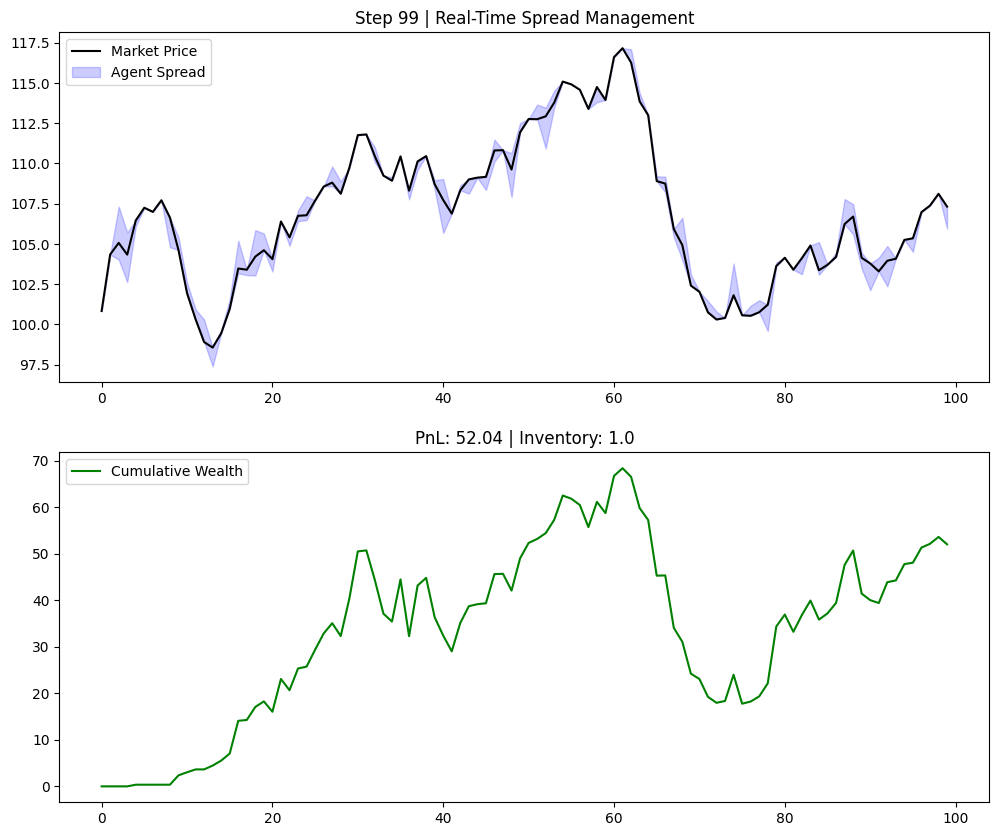

In [23]:
# Block 4: Live Simulation
obs, _ = env_a.reset()
prices, wealths, bids, asks = [], [], [], []

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for i in range(100):
    action, _ = model_a.predict(obs)
    obs, _, done, _, info = env_a.step(action)

    prices.append(obs[0]); wealths.append(info['wealth'])
    bids.append(obs[0] - action[0]); asks.append(obs[0] + action[1])

    ax1.clear(); ax2.clear()
    ax1.plot(prices, color='black', label="Market Price", linewidth=1.5)
    ax1.fill_between(range(len(prices)), bids, asks, color='blue', alpha=0.2, label='Agent Spread')
    ax1.set_title(f"Step {i} | Real-Time Spread Management")
    ax1.legend(loc='upper left')

    ax2.plot(wealths, color='green', label="Cumulative Wealth")
    ax2.set_title(f"PnL: {info['wealth']:.2f} | Inventory: {obs[1]}")
    ax2.legend(loc='upper left')

    display(fig); clear_output(wait=True); time.sleep(0.05)
    if done: break